In [1]:
!pip install numpy pandas matplotlib torch keras scikit-learn scipy tensorflow deepctr-torch

In [3]:
import numpy as np
np.float = float
import random
import pandas as pd

import torch

from sklearn.neighbors import NearestNeighbors

from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix


# loading and preparing the data
reviews = pd.read_json("Amazon_Fashion.jsonl", lines=True)
reviews = reviews[reviews["rating"] != 3]
reviews = reviews[reviews["timestamp"] > "2015-01-01"]
reviews["year"] = reviews["timestamp"].apply(lambda x: x.year)
reviews["month"] = reviews["timestamp"].apply(lambda x: x.month)
reviews["day"] = reviews["timestamp"].apply(lambda x: x.day)
#create reference dataframe
reference_data = reviews[reviews["timestamp"] > "2015-01-01"]
reference_data = reference_data[reference_data["timestamp"] < "2020-01-01"]
#create evaluation dataframe
evaluation_data = reviews[reviews["timestamp"] >= "2020-01-01"]
evaluation_data = evaluation_data.set_index(evaluation_data["timestamp"])
evaluation_data.sort_index(inplace=True)
# remove products that appear after ref
evaluation_data_with_old_products = evaluation_data[
    evaluation_data["parent_asin"].isin(reference_data["parent_asin"])]
#create rolling window
rolling = evaluation_data_with_old_products["rating"].rolling("30D").mean()

In [4]:
#encode features in the reviews for use in ml model
sparse_features = ["parent_asin", "user_id", "year", "month", "day"]
for feat in sparse_features:
    lbe = LabelEncoder()
    reviews[feat] = lbe.fit_transform(reviews[feat])


def create_matrix(df):
    N = len(df['user_id'].unique())
    M = len(df['product_id'].unique())

    # Map Ids to indices
    user_mapper = dict(zip(np.unique(df["user_id"]), list(range(N))))
    product_mapper = dict(zip(np.unique(df["product_id"]), list(range(M))))

    # Map indices to IDs
    user_inv_mapper = dict(zip(list(range(N)), np.unique(df["user_id"])))
    product_inv_mapper = dict(zip(list(range(M)), np.unique(df["product_id"])))

    user_index = [user_mapper[i] for i in df['user_id']]
    product_index = [product_mapper[i] for i in df['product_id']]

    X = csr_matrix((df["rating"], (product_index, user_index)), shape=(M, N))

    return X, user_mapper, product_mapper, user_inv_mapper, product_inv_mapper


#rename for use in function
reference_data["product_id"] = reference_data["parent_asin"]
X, user_mapper, product_mapper, user_inv_mapper, product_inv_mapper = create_matrix(
    reference_data)
#train ml model
kNN = NearestNeighbors(n_neighbors=5, algorithm="brute", metric='cosine')
kNN.fit(X)


def find_similar_products(product_id, X, k, metric='cosine',
                          show_distance=False):
    neighbour_ids = []

    product_ind = product_mapper[product_id]
    product_vec = X[product_ind]
    k += 1
    product_vec = product_vec.reshape(1, -1)
    neighbour = kNN.kneighbors(product_vec, return_distance=show_distance)
    for i in range(0, k):
        n = neighbour.item(i)
        neighbour_ids.append(product_inv_mapper[n])
    neighbour_ids.pop(0)
    return neighbour_ids




In [5]:
#sample reviews from products
sampled = evaluation_data_with_old_products.sample(10000)
sampled.sort_index(inplace=True)
rolling = sampled["rating"].rolling("30D").mean()

#store the predictions of the recommendation system (takes a long time)
preds = []
for i in range(len(sampled)):
    preds.append(find_similar_products(sampled["parent_asin"].values[i], X, 4))
preds
#store the recommendations in dataframe
sampled["recommendation"] = preds
reviews_copy = pd.read_json("Amazon_Fashion.jsonl", lines=True)
#ensure same strutcture as ctr-predictor training data
reviews_copy = reviews_copy[reviews_copy["rating"] != 3]
reviews_copy = reviews_copy[reviews_copy["timestamp"] > "2015-01-01"]
# create a mapper for the ctr-predictor
fashion_mapper = dict(
    zip(reviews_copy["parent_asin"].unique(), reviews["parent_asin"].unique()))
# create a mapper for the ctr-predictor
fashion_user_mapper = dict(
    zip(reviews_copy["user_id"].unique(), reviews["user_id"].unique()))
# load the ctr-predictor
model = torch.load("model_formatted_fashion_cpu_v2")

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_19169/3880244259.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("model_formatted_fashion_

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_19169/2880575555.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for j in range(len(sampled["recommendation"][i])):
/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_19169/2880575555.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fashion_mapper[sampled["recommendation"][i][j]]),
/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_19169/2880575555.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To 

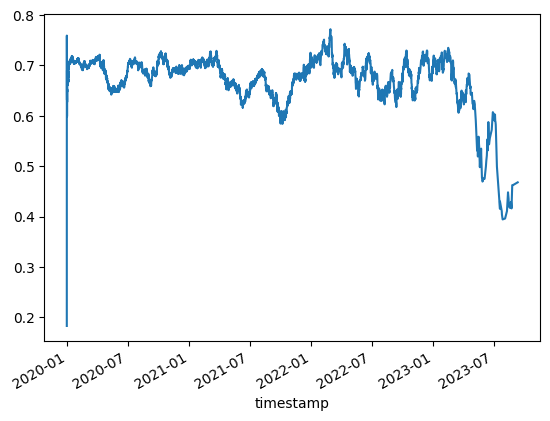

In [6]:

# calculate click-through-rate for the recommendations
def mean_predicted_ctr():
    res = []
    for i in range(len(sampled)):
        temp = []
        for j in range(len(sampled["recommendation"][i])):
            temp.append(model.predict({"parent_asin": pd.Series(
                fashion_mapper[sampled["recommendation"][i][j]]),
                                       "user_id": pd.Series(
                                           fashion_user_mapper[
                                               sampled["user_id"][i]]),
                                       "year": pd.Series(
                                           sampled["year"][i] - 2015),
                                       "month": pd.Series(
                                           sampled["month"][i] - 1),
                                       "day": pd.Series(
                                           sampled["day"][i] - 1)}))
        res.append(temp)
    return res


ctr_list = mean_predicted_ctr()
ctr_list
means = []
for i in range(len(ctr_list)):
    means.append(np.mean(ctr_list[i]))
series_means = pd.Series(means, index=sampled["timestamp"])
rolling_means = series_means.rolling("30D").mean()
rolling_means.plot()
# create labels for the drift-detectors
correct_recommendations = []
for i in range(len(ctr_list)):
    for j in range(4):
        correct_recommendations.append(random.choices([0, 1], weights=[
            1 - ctr_list[i][j][0][0], ctr_list[i][j][0][0]])[0])

In [7]:
# Now the drift detection with embeddings
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

embedding_dim = sum([emb.embedding_dim for emb in model.embedding_dict.values()])
bar_E = np.zeros((embedding_dim,))
Sigma = np.eye(embedding_dim)*0.1
M_values = []
threshold = None
alpha = 0.01
threshold_multiplier = 3

evaluation_data_sorted = sampled

# Conditional preprocessing for features
def preprocess_feature(feat, values):
    if feat == 'year':
        # Map years to a range of 0–9999
        return values.astype(int) % 10000
    elif feat == 'month':
        # Map months to a range of 0–11
        return values.astype(int) % 12
    elif feat == 'day':
        # Map days to a range of 0–30
        return values.astype(int) % 31
    else:
        # General hashing for other features
        return values.astype(str).map(lambda x: hash(x) % 1e6).astype(int)

def compute_batch_embeddings(model, batch_input, device='cpu'):
    with torch.no_grad():
        print("\n[DEBUG] Computing batch embeddings")
        for k, v in batch_input.items():
            print(f"[DEBUG] Feature: {k}, Values: {v[:10]} (Showing first 10)")
            batch_input[k] = torch.tensor(np.asarray(v, dtype=np.int64), dtype=torch.long, device=device)
        
        emb_list = []
        for feat, emb_layer in model.embedding_dict.items():
            print(f"[DEBUG] Embedding layer for feature: {feat}")
            print(f"[DEBUG] Input indices for feature '{feat}': {batch_input[feat][:10]} (Showing first 10)")
            
            # Check for invalid indices
            max_index = emb_layer.weight.size(0)
            if (batch_input[feat] >= max_index).any():
                raise IndexError(
                    f"Invalid index detected in feature '{feat}'. "
                    f"Max valid index: {max_index - 1}, "
                    f"Input indices: {batch_input[feat][:10]}"
                )
            
            emb_list.append(emb_layer(batch_input[feat]))
        
        batch_embeddings = torch.cat(emb_list, dim=-1)
        print(f"[DEBUG] Batch embeddings shape: {batch_embeddings.shape}")
        batch_embeddings = batch_embeddings.cpu().numpy()
        E_t = np.mean(batch_embeddings, axis=0)
        print(f"[DEBUG] Mean embedding for batch (E_t): {E_t[:10]} (Showing first 10 dimensions)")
        return E_t


def mahalanobis_distance(E_t, bar_E, Sigma):
    diff = E_t - bar_E
    Sigma_inv = np.linalg.inv(Sigma + np.eye(Sigma.shape[0])*1e-6)
    M_t = np.sqrt(diff.T @ Sigma_inv @ diff)
    return M_t

num_samples = len(evaluation_data_sorted)
# Set a larger batch size
batch_size = 1024
num_batches = (num_samples + batch_size - 1) // batch_size

# Debugging during batch processing
for b in range(num_batches):
    print(f"\n[DEBUG] Processing batch {b + 1}/{num_batches}")
    batch_df = evaluation_data_sorted.iloc[b * batch_size:(b + 1) * batch_size]
    if batch_df.empty:
        print("[DEBUG] Batch is empty, skipping.")
        continue

    batch_input = {}
    for feat in sparse_features:
        print(f"[DEBUG] Processing feature: {feat}")
        batch_df.loc[:, feat] = preprocess_feature(feat, batch_df[feat])
        batch_input[feat] = batch_df[feat].values
        print(f"[DEBUG] First 10 values after preprocessing: {batch_input[feat][:10]}")

    E_t = compute_batch_embeddings(model, batch_input, device)

    # Update bar_E and Sigma
    old_bar_E = bar_E.copy()
    bar_E = (1 - alpha) * bar_E + alpha * E_t
    diff = E_t - bar_E
    Sigma = (1 - alpha) * Sigma + alpha * (np.outer(diff, diff))

    M_t = mahalanobis_distance(E_t, bar_E, Sigma)
    M_values.append(M_t)
    print(f"[DEBUG] M_t: {M_t}")

    if len(M_values) > 100:
        recent_values = M_values[-100:]
        mean_M = np.mean(recent_values)
        std_M = np.std(recent_values)
        threshold = mean_M + threshold_multiplier * std_M
        print(f"[DEBUG] Updated threshold: {threshold}")

    if threshold is not None and M_t > threshold:
        print(f"[ALERT] Drift detected at batch {b}, timestamp: {batch_df['timestamp'].iloc[-1]}, M_t={M_t:.4f}, threshold={threshold:.4f}")


# Save drift distances and thresholds
np.save('drift_distances2.npy', np.array(M_values))
np.save('drift_thresholds2.npy', np.array(threshold))


[DEBUG] Processing batch 1/10
[DEBUG] Processing feature: parent_asin
[DEBUG] First 10 values after preprocessing: [341056 63360 289856 94912 498304 792576 14016 792512 696064 471232]
[DEBUG] Processing feature: user_id
[DEBUG] First 10 values after preprocessing: [190400 176320 789760 71808 761344 11072 908032 418688 15744 942336]
[DEBUG] Processing feature: year
[DEBUG] First 10 values after preprocessing: [2020 2020 2020 2020 2020 2020 2020 2020 2020 2020]
[DEBUG] Processing feature: month
[DEBUG] First 10 values after preprocessing: [1 1 1 1 1 1 1 1 1 1]
[DEBUG] Processing feature: day
[DEBUG] First 10 values after preprocessing: [1 1 1 1 1 1 1 1 1 1]

[DEBUG] Computing batch embeddings
[DEBUG] Feature: parent_asin, Values: [341056 63360 289856 94912 498304 792576 14016 792512 696064 471232] (Showing first 10)
[DEBUG] Feature: user_id, Values: [190400 176320 789760 71808 761344 11072 908032 418688 15744 942336] (Showing first 10)
[DEBUG] Feature: year, Values: [2020 2020 2020 2020

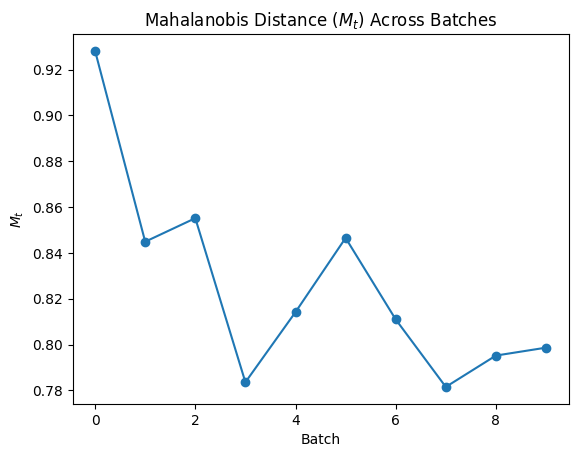

In [8]:
#################################
# Visualization
#################################
import matplotlib.pyplot as plt
plt.plot(range(len(M_values)), M_values, marker='o')
plt.title("Mahalanobis Distance ($M_t$) Across Batches")
plt.xlabel("Batch")
plt.ylabel("$M_t$")
plt.show()
